In [6]:
from google.colab import files
uploaded=files.upload()

Saving fake_job_postings.csv to fake_job_postings (1).csv


In [7]:
print(uploaded.keys())

dict_keys(['fake_job_postings (1).csv'])


In [8]:
import pandas as pd
file=list(uploaded.keys())[0]
df=pd.read_csv(file)
print("Dataset saved")
print("rows",df.shape[0])
print("col",df.shape[1])

Dataset saved
rows 17880
col 18


In [9]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [10]:
df.columns.tolist()

['job_id',
 'title',
 'location',
 'department',
 'salary_range',
 'company_profile',
 'description',
 'requirements',
 'benefits',
 'telecommuting',
 'has_company_logo',
 'has_questions',
 'employment_type',
 'required_experience',
 'required_education',
 'industry',
 'function',
 'fraudulent']

In [14]:
df["fraudulent"].value_counts()

,count
fraudulent,
0,17014
1,866


In [15]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [16]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

salary_range           15012
department             11547
required_education      8105
benefits                7212
required_experience     7050
function                6455
industry                4903
employment_type         3471
company_profile         3308
requirements            2696
location                 346
description                1
dtype: int64


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [17]:
fraud_percentage = df["fraudulent"].value_counts(normalize=True) * 100

print(fraud_percentage)

fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64


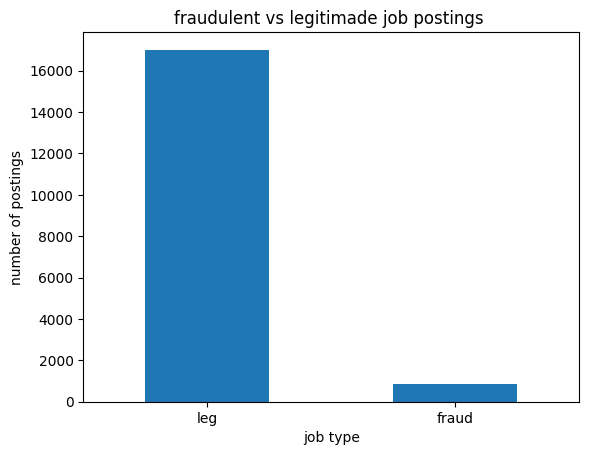

In [20]:
import matplotlib.pyplot as plt
df['fraudulent'].value_counts().plot(kind="bar")
plt.title("fraudulent vs legitimade job postings ")
plt.xlabel("job type")
plt.ylabel("number of postings")
plt.xticks([0,1],["leg","fraud"],rotation=0)
plt.show()

In [21]:
pd.crosstab(
    df["has_company_logo"],
    df["fraudulent"],
    normalize="index"
) * 100

fraudulent,0,1
has_company_logo,,
0,84.071038,15.928962
1,98.009845,1.990155


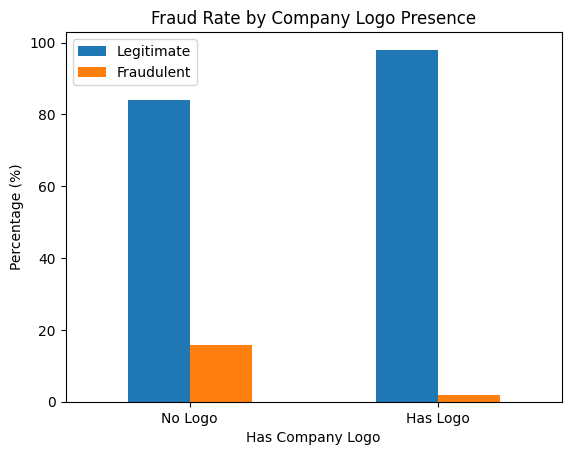

In [22]:
import matplotlib.pyplot as plt

fraud_rate = pd.crosstab(
    df["has_company_logo"],
    df["fraudulent"],
    normalize="index"
) * 100

fraud_rate.plot(kind="bar")

plt.title("Fraud Rate by Company Logo Presence")
plt.xlabel("Has Company Logo")
plt.ylabel("Percentage (%)")
plt.xticks([0, 1], ["No Logo", "Has Logo"], rotation=0)
plt.legend(["Legitimate", "Fraudulent"])

plt.show()

In [23]:
pd.crosstab(
    df["telecommuting"],
    df["fraudulent"],
    normalize="index"
) * 100

fraudulent,0,1
telecommuting,,
0,95.313504,4.686496
1,91.655802,8.344198



TELECOMMUTING
fraudulent         0     1
telecommuting             
0              95.31  4.69
1              91.66  8.34

HAS_COMPANY_LOGO
fraudulent            0      1
has_company_logo              
0                 84.07  15.93
1                 98.01   1.99

HAS_QUESTIONS
fraudulent         0     1
has_questions             
0              93.22  6.78
1              97.16  2.84

FRAUD RATE: employment_type
                 count  fraud_rate_%
employment_type                     
Part-time          797          9.28
Other              227          6.61
Full-time        11620          4.22
Contract          1524          2.89
Temporary          241          0.83

FRAUD RATE: required_experience
                     count  fraud_rate_%
required_experience                     
Executive              141          7.09
Entry level           2697          6.64
Not Applicable        1116          5.38
Director               389          4.37
Mid-Senior level      3809          2.97
Inte

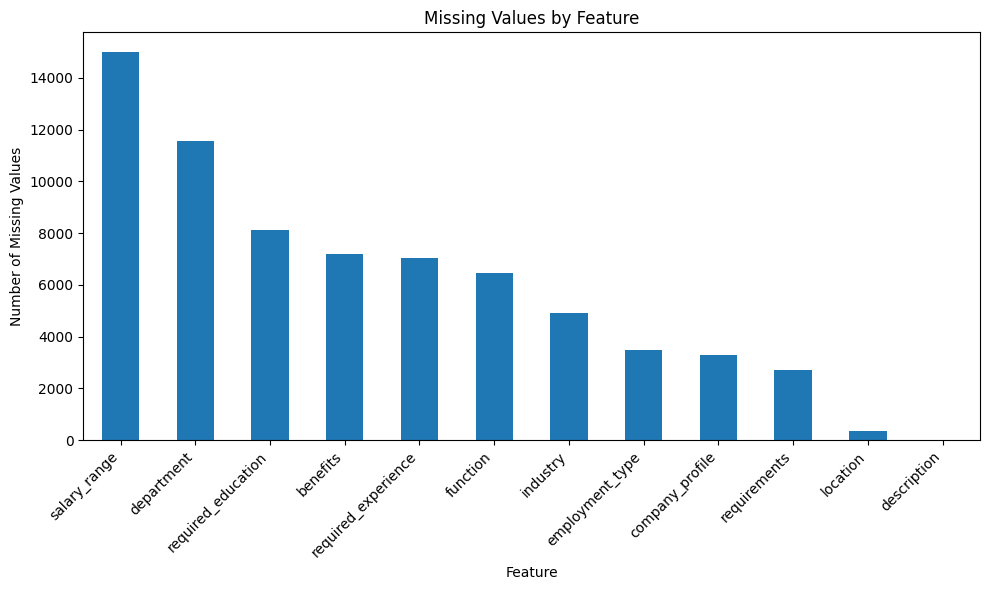

<Figure size 800x500 with 0 Axes>

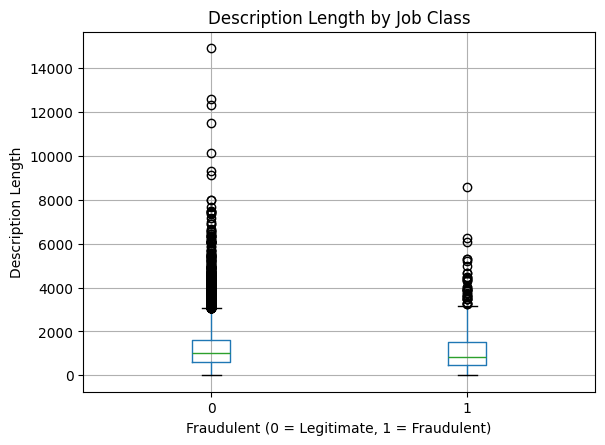

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

binary_Cols=["telecommuting","has_company_logo","has_questions"]
for col in binary_Cols:
  print("\n"+"="*50)
  print(col.upper())
  print("="*50)

  result=pd.crosstab(
      df[col],df["fraudulent"],normalize="index")*100

  print(result.round(2))


categorical_cols=["employment_type","required_experience","required_education","industry","function"]
for col in categorical_cols:

    print("\n" + "="*50)
    print(f"FRAUD RATE: {col}")
    print("="*50)

    temp = (
        df.groupby(col)["fraudulent"]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=False)
    )

    temp["fraud_rate_%"] = temp["mean"] * 100

    print(
        temp[temp["count"] >= 20]
        .sort_values("fraud_rate_%", ascending=False)
        .head(10)[["count", "fraud_rate_%"]]
        .round(2)
    )
print("\n" + "="*50)
print("MISSING VALUES BY FRAUD CLASS")
print("="*50)

text_cols = [
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for col in text_cols:

    missing_rate = (
        df.groupby("fraudulent")[col]
        .apply(lambda x: x.isna().mean() * 100)
    )

    print(f"\n{col}")
    print(missing_rate.round(2))


# -------------------------------
# 4. Text length analysis
# -------------------------------

for col in text_cols:

    df[f"{col}_length"] = (
        df[col]
        .fillna("")
        .astype(str)
        .str.len()
    )

print("\n" + "="*50)
print("AVERAGE TEXT LENGTH BY CLASS")
print("="*50)

for col in text_cols:

    result = df.groupby("fraudulent")[f"{col}_length"].mean()

    print(f"\n{col}:")
    print(result.round(2))


# -------------------------------
# 5. URL / email / phone signals
# -------------------------------

df["url_count"] = (
    df["description"]
    .fillna("")
    .astype(str)
    .str.count(r"http|www\.")
)

df["email_count"] = (
    df["description"]
    .fillna("")
    .astype(str)
    .str.count(r"[\w\.-]+@[\w\.-]+\.\w+")
)

df["phone_count"] = (
    df["description"]
    .fillna("")
    .astype(str)
    .str.count(r"\+?\d[\d\s\-\(\)]{7,}")
)

print("\n" + "="*50)
print("AVERAGE URL / EMAIL / PHONE COUNTS")
print("="*50)

print(
    df.groupby("fraudulent")[
        ["url_count", "email_count", "phone_count"]
    ].mean().round(3)
)


# -------------------------------
# 6. Visualize missing values
# -------------------------------

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
missing.plot(kind="bar")

plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


# -------------------------------
# 7. Text length comparison
# -------------------------------

plt.figure(figsize=(8, 5))

df.boxplot(
    column="description_length",
    by="fraudulent"
)

plt.title("Description Length by Job Class")
plt.suptitle("")
plt.xlabel("Fraudulent (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Description Length")

plt.show()
